In [15]:
company_to_ticker = {
    "apple": "AAPL",
    "samsung": "005930.KS",
    "tcs": "TCS.NS",
    "microsoft": "MSFT",
    "google": "GOOGL",
    "amazon": "AMZN",
    "infosys": "INFY.NS",
    "wipro": "WIPRO.NS"
    #  Add more as needed
}


In [16]:
company_name = input("Enter company name (e.g., Apple, Samsung, TCS): ").lower()


if company_name in company_to_ticker:
    ticker = company_to_ticker[company_name]
    print(f"✅ Found ticker: {ticker}")
else:
    raise ValueError("❌ Company name not recognized. Please try a valid one.")


✅ Found ticker: WIPRO.NS


In [17]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [18]:

start_date = '2020-01-01'
end_date = '2025-05-03'

In [19]:
data = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [20]:
os.makedirs("../data", exist_ok=True)
data.to_csv("../data/stock_data.csv")
print("✅ Data downloaded and saved as '../data/stock_data.csv'")


✅ Data downloaded and saved as '../data/stock_data.csv'


In [21]:


# Define the function to download and save data
def download_and_save_data(ticker):
    try:
        # Fetch stock data for the given ticker symbol
        stock_data = yf.download(ticker, period="5y", interval="1d")
        
        # Check if data is empty
        if stock_data.empty:
            print(f"No data found for ticker: {ticker}")
            return
        
        # Create a directory for saving data if it doesn't exist
        os.makedirs("../data", exist_ok=True)
        
        # Use the ticker symbol as the filename (or you can extract the company name)
        filename = f"../data/{ticker}_stock_data.csv"
        
        # Save the data to the CSV file
        stock_data.to_csv(filename)
        
        print(f"✅ Data downloaded and saved as '{filename}'")
    
    except Exception as e:
        print(f"❌ Failed to download data for ticker: {ticker}. Error: {str(e)}")

# Example of entering the company ticker symbol  # Convert to uppercase for consistency
download_and_save_data(ticker)


[*********************100%***********************]  1 of 1 completed

✅ Data downloaded and saved as '../data/WIPRO.NS_stock_data.csv'


In [22]:
data = pd.read_csv("../data/stock_data.csv", parse_dates=True)
print(data.head())
print(data.describe())
print(data.columns)
print(data.info())

        Price               Close                High                 Low  \
0      Ticker            WIPRO.NS            WIPRO.NS            WIPRO.NS   
1        Date                 NaN                 NaN                 NaN   
2  2020-01-01  119.50023651123047  119.95855246358637  118.77657741968716   
3  2020-01-02  119.78971099853516  120.56160966359536  118.84895558972727   
4  2020-01-03  121.14053344726562  121.91243205232186  119.33138573963885   

                 Open    Volume  
0            WIPRO.NS  WIPRO.NS  
1                 NaN       NaN  
2  118.92131071028402   2827732  
3  118.96956544627807   2887932  
4  120.36862748076852   6762808  
             Price               Close              High                 Low  \
count         1322                1321              1321                1321   
unique        1322                1238              1317                1320   
top     2025-05-02  188.17648315429688  91.0647728855116  305.04998779296875   
freq         

In [23]:
# Ensure the 'Close' column is numeric
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# Calculate moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()


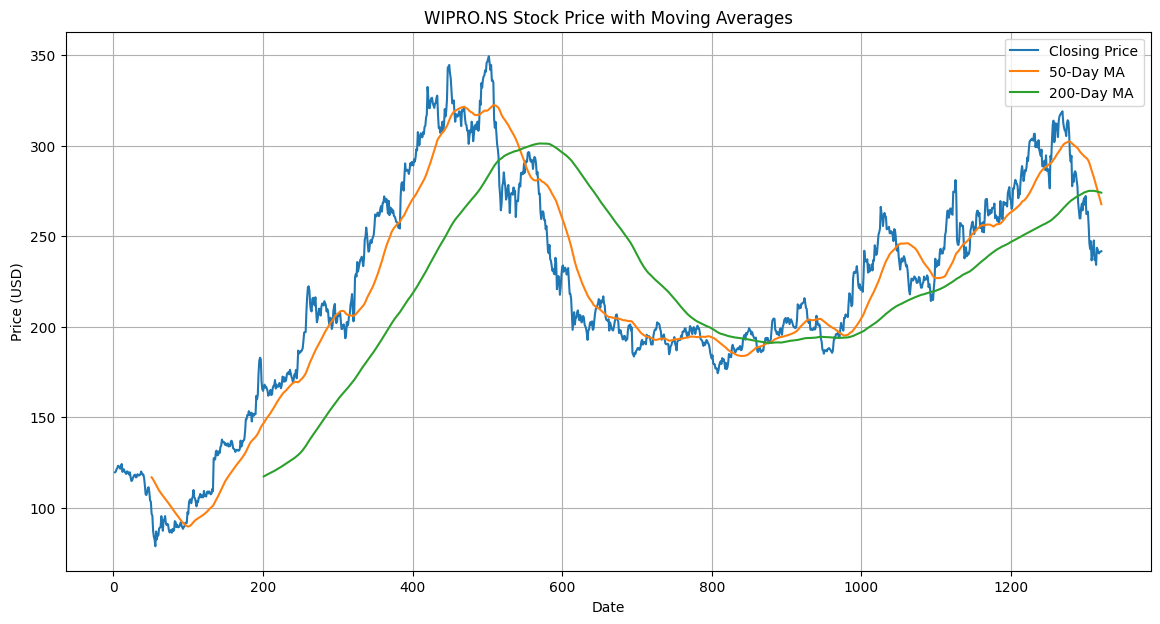

In [24]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Closing Price')
plt.plot(data['MA50'], label='50-Day MA')
plt.plot(data['MA200'], label='200-Day MA')
plt.title(f'{ticker} Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

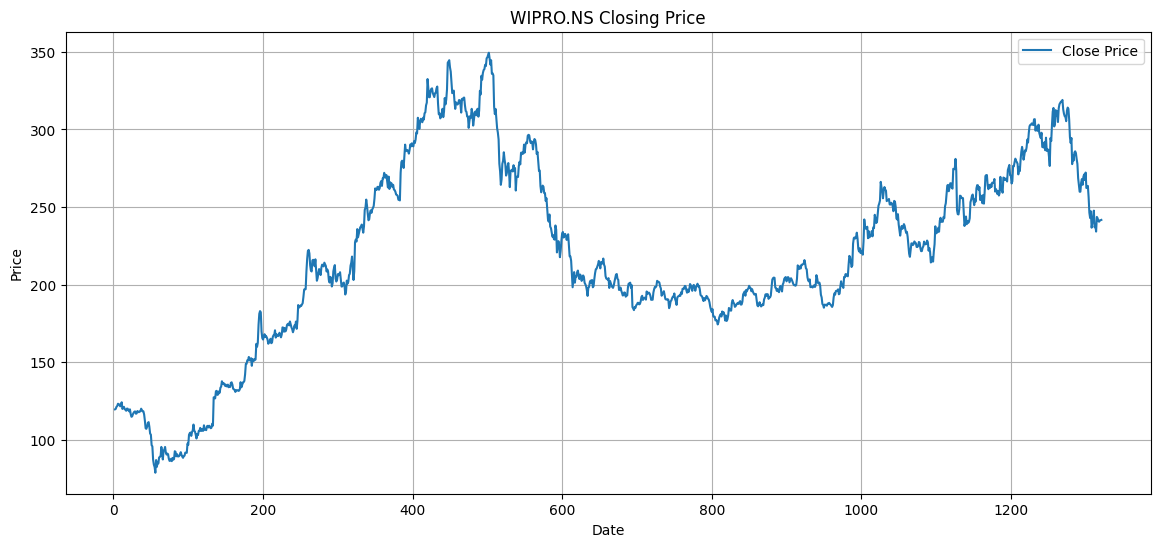

In [25]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

<Figure size 1400x600 with 0 Axes>

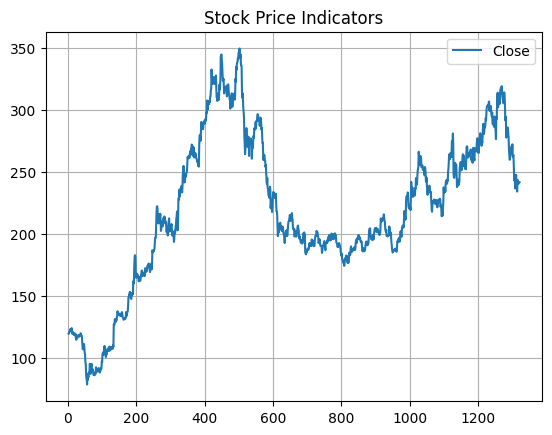

In [26]:
plt.figure(figsize=(14, 6))
data[['Open', 'High', 'Low', 'Close']].plot(title="Stock Price Indicators")
plt.grid()
plt.show()

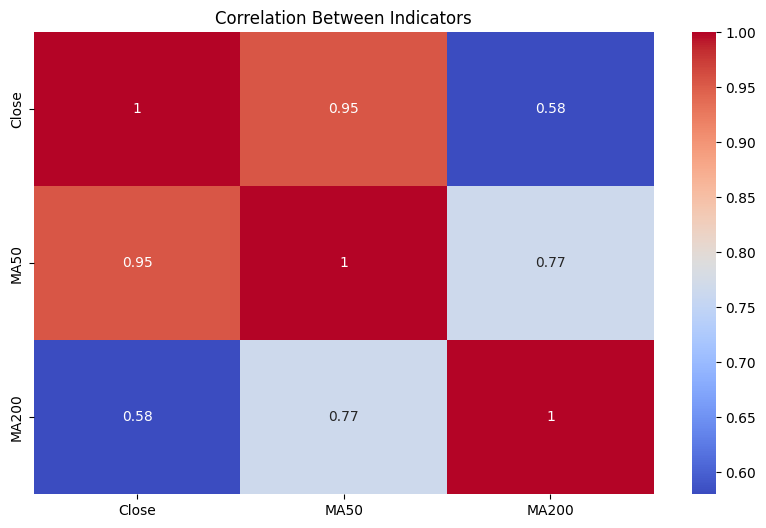

In [27]:
# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Indicators")
plt.show()

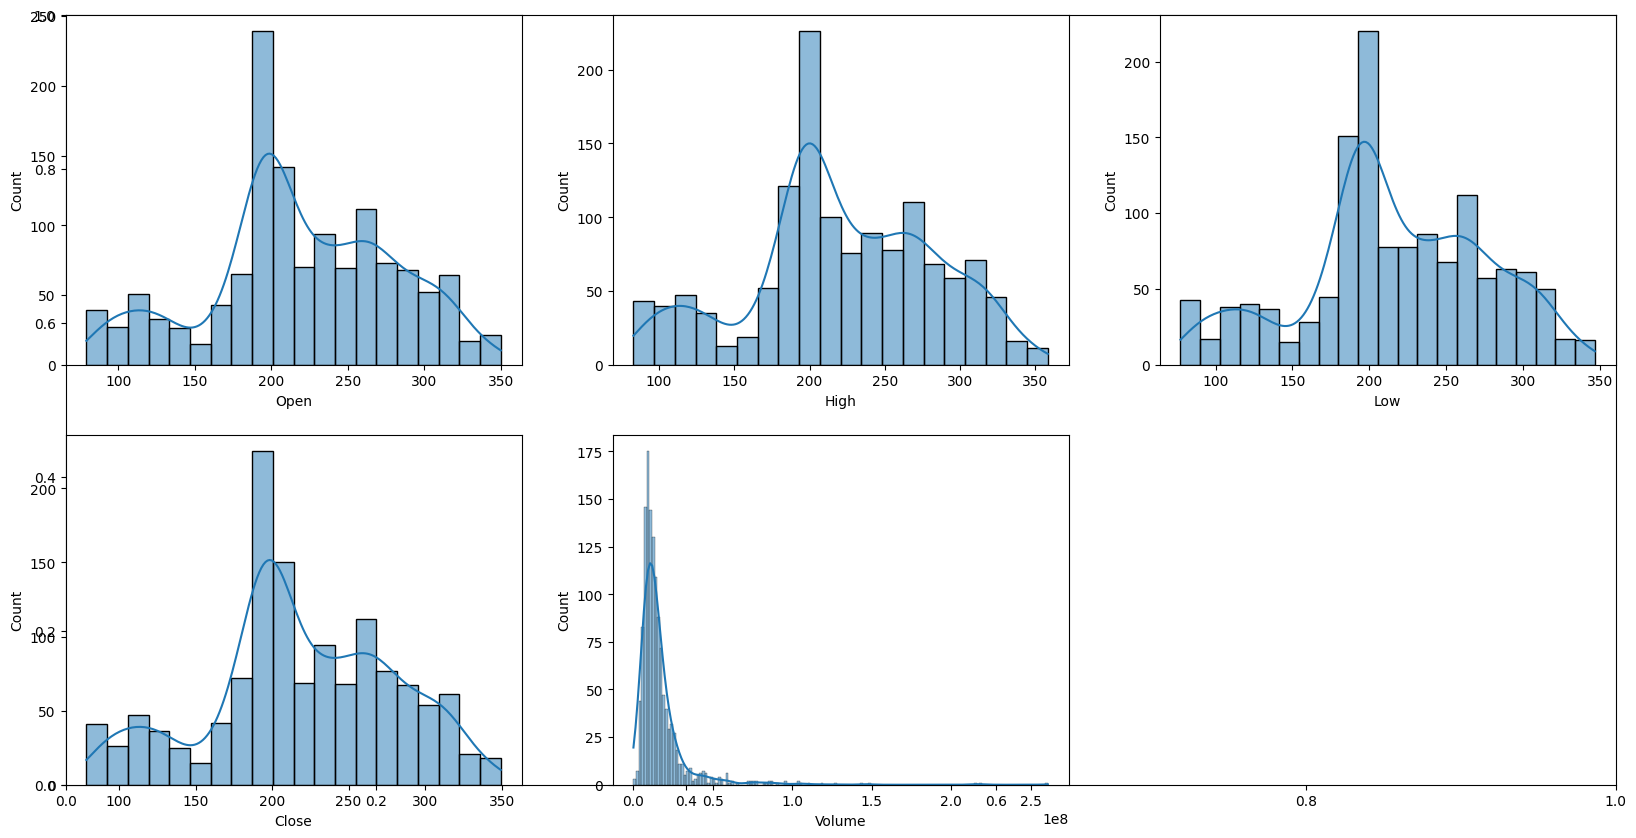

In [28]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Convert columns to numeric, coercing errors to NaN
for col in features:
    data[col] = pd.to_numeric(data[col], errors='coerce')

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[col], kde=True)  # Updated to use sns.histplot instead of sns.distplot (deprecated)
plt.show()